# TRABAJO MATRIZ DE CONFUSIÓN

1) id: identificador único
2) gender: "Hombre", "Mujer" u "Otro"
3) age: edad del paciente
4) hypertension: 0 si el paciente no tiene hipertensión, 1 si el paciente tiene hipertensión
5) heart_disease: 0 si el paciente no tiene ninguna enfermedad cardíaca, 1 si el paciente tiene una enfermedad cardíaca
6) ever_casado: "No" o "Sí"
7) work_type: "niños", "Govt_jov", "Never_worked", "Privado" o "Autónomo"
8) Residence_type: "Rural" o "Urban"
9) avg_glucose_nivel: nivel promedio de glucosa en sangre
10) bmi: índice de masa corporal
11) smoking_status: "anteriormente fumado", "nunca fumado", "humo" o "Desconocido"*
12) stroke: 1 si el paciente tuvo un accidente cerebrovascular o 0 si no
*Nota: "Desconocido" en smoking_status significa que la información no está disponible para este paciente

### LIBRERIAS 

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, r2_score, mean_squared_error, roc_curve, roc_auc_score, ConfusionMatrixDisplay

## 1. Carga de datos

In [3]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

## 2. Exploración inicial

In [4]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
df.shape

(5110, 12)

In [6]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [7]:
df.corr(numeric_only=True)['stroke'].abs().sort_values(ascending=False)[1:]

age                  0.245257
heart_disease        0.134914
avg_glucose_level    0.131945
hypertension         0.127904
bmi                  0.042374
id                   0.006388
Name: stroke, dtype: float64

## 3. Limpieza de los datos

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [9]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [12]:
df.shape

(4909, 12)

## 4. Selección de variables

In [13]:
df = df.drop(columns=["id"])
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [14]:
df = pd.get_dummies(df,dtype=int)

In [15]:
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0
2,80.0,0,1,105.92,32.5,1,0,1,0,0,...,0,1,0,0,1,0,0,0,1,0
3,49.0,0,0,171.23,34.4,1,1,0,0,0,...,0,1,0,0,0,1,0,0,0,1
4,79.0,1,0,174.12,24.0,1,1,0,0,0,...,0,0,1,0,1,0,0,0,1,0
5,81.0,0,0,186.21,29.0,1,0,1,0,0,...,0,1,0,0,0,1,0,1,0,0


In [16]:
df.shape

(4909, 22)

In [17]:
df['stroke'].value_counts()

stroke
0    4700
1     209
Name: count, dtype: int64

## 5. Definicion de X e y

In [18]:
X = df.drop(["stroke"],axis=1)
y = df["stroke"]

print(X.shape)
print(y.shape)

(4909, 21)
(4909,)


## 6. Escalado

In [19]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [20]:
print("Primeros registros de X escalada:")
print(X[:5, :3])

Primeros registros de X escalada:
[[ 1.07013796 -0.31806673  4.38196829]
 [ 1.64656262 -0.31806673  4.38196829]
 [ 0.27201152 -0.31806673 -0.22820795]
 [ 1.60222226  3.14399438 -0.22820795]
 [ 1.69090297 -0.31806673 -0.22820795]]


## 7. Train/Test split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (3927, 21)
X_test:  (982, 21)
y_train: (3927,)
y_test:  (982,)


## 8. Entrenamiento de modelos de clasificación

### LogisticRegression sin "class_weight='balanced'"

In [22]:
model_lr = LogisticRegression(max_iter=1000) 
model_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
y_pred_lr = model_lr.predict(X_test)
print(accuracy_score(y_test, y_pred_lr))

0.9572301425661914


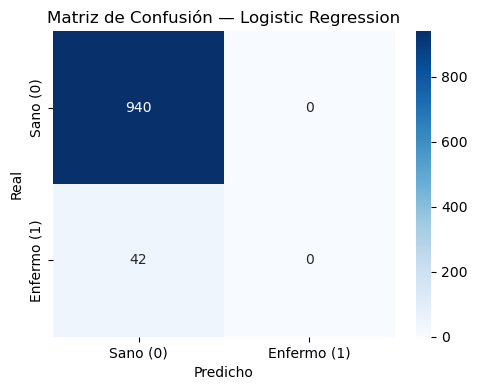

In [24]:
# 1. Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_lr)

# 2. Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — Logistic Regression")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


### LogisticRegression con "class_weight='balanced'"

In [25]:
model_lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced') 
model_lr_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [26]:
y_pred_lr_balanced = model_lr_balanced.predict(X_test)
print(accuracy_score(y_test, y_pred_lr_balanced))

0.7566191446028513


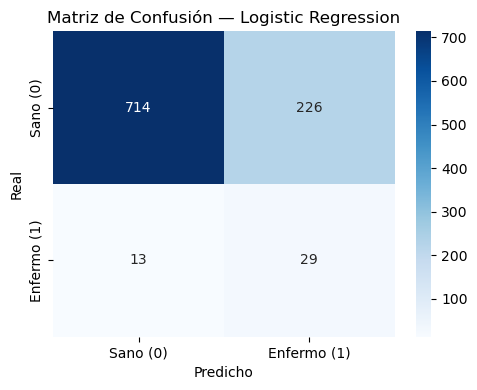

In [27]:
# 1. Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_lr_balanced)

# 2. Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — Logistic Regression")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


### RandomForestClassifier sin "class_weight='balanced'"

In [ ]:
rf_clf = RandomForestClassifier(n_estimators=600, n_jobs=1, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=600, n_jobs=1, random_state=42)

In [29]:
y_pred_rf = rf_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_rf))

0.9541751527494908


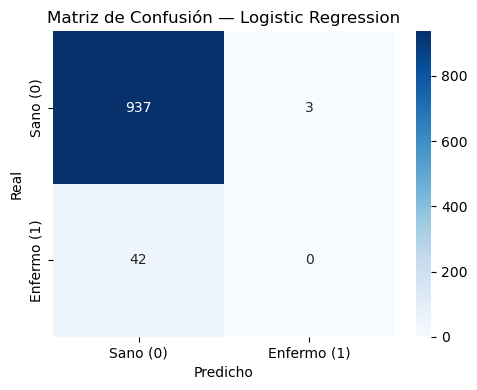

In [30]:
# 1. Calculamos las matrices numéricas
cm_lr = confusion_matrix(y_test, y_pred_rf)

# 2. Visualización de la Matriz para Logistic Regression
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sano (0)", "Enfermo (1)"],
            yticklabels=["Sano (0)", "Enfermo (1)"])
plt.title("Matriz de Confusión — Logistic Regression")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


### RandomForestClassifier con "class_weight='balanced'"